**LOADING PACKAGES AND DATASET**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nzjAecNRkThhdPeZeczo")
project = rf.workspace("colins-workspace-zcf3w").project("frisbee-5swwf")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Frisbee-2 in yolov8:: 100%|██████████| 1300/1300 [00:00<00:00, 7597.19it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


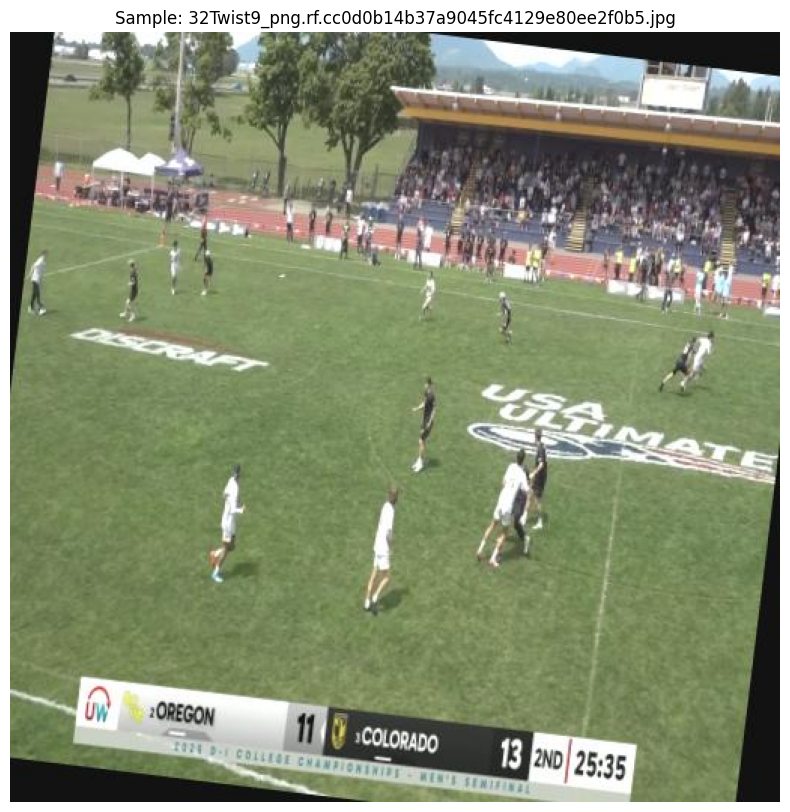

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

image_dir = os.path.join(dataset.location, "train/images")
random_image = random.choice(os.listdir(image_dir))
img_path = os.path.join(image_dir, random_image)

img = mpimg.imread(img_path)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title(f"Sample: {random_image}")
plt.axis('off')
plt.show()

**DATA SPLIT AND TRAIN**

In [ ]:
import os, shutil, random, yaml

src_images = '/content/Frisbee-2/train/images'
src_labels = '/content/Frisbee-2/train/labels'
base = '/content/Frisbee-2'

label_stems = {f.rsplit('.', 1)[0] for f in os.listdir(src_labels) if f.endswith('.txt')}

images = []
for f in os.listdir(src_images):
    if f.endswith(('.jpg', '.png', '.jpeg')):
        stem = f.rsplit('.', 1)[0]
        if stem in label_stems:
            images.append(f)

print(f"Matched images with labels: {len(images)}")

random.seed(42)
random.shuffle(images)

n = len(images)
train_end = int(n * 0.7)
valid_end = int(n * 0.9)

splits = {
    'train': images[:train_end],
    'valid': images[train_end:valid_end],
    'test':  images[valid_end:]
}

print(f"Train: {len(splits['train'])} | Valid: {len(splits['valid'])} | Test: {len(splits['test'])}")

for split, files in splits.items():
    for folder in ['images', 'labels']:
        os.makedirs(os.path.join(base, f'{split}_new', folder), exist_ok=True)
    for img_file in files:
        lbl_file = img_file.rsplit('.', 1)[0] + '.txt'
        shutil.copy(os.path.join(src_images, img_file),
                    os.path.join(base, f'{split}_new', 'images', img_file))
        shutil.copy(os.path.join(src_labels, lbl_file),
                    os.path.join(base, f'{split}_new', 'labels', lbl_file))

for split in ['train', 'valid', 'test']:
    old = os.path.join(base, split)
    new = os.path.join(base, f'{split}_new')
    if os.path.exists(old):
        shutil.rmtree(old)
    os.rename(new, old)

print("Split done!")

with open(os.path.join(base, 'data.yaml')) as f:
    data = yaml.safe_load(f)

data['train'] = f'{base}/train/images'
data['val']   = f'{base}/valid/images'
data['test']  = f'{base}/test/images'

with open(os.path.join(base, 'data.yaml'), 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("Yaml updated! Ready to train.")

Matched images with labels: 649
Train: 454 | Valid: 130 | Test: 65
Split done!
Yaml updated! Ready to train.


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/Frisbee-2/data.yaml',
    epochs=50,
    imgsz=640,
    plots=True,
    project='/content/drive/MyDrive/frisbee_model',
    name='run1'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Frisbee-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

RuntimeError: Dataset '/content/Frisbee-2/data.yaml' error ❌ '/content/Frisbee-2/data.yaml' does not exist

**SAVING WEIGHTS, DISPLAYING SAMPLE BOUNDING BOXES, AND ACCURACY**

In [ ]:
from ultralytics import YOLO
from google.colab import drive
drive.mount('/content/drive')

model = YOLO('/content/drive/MyDrive/frisbee_model/run1/weights/best.pt')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


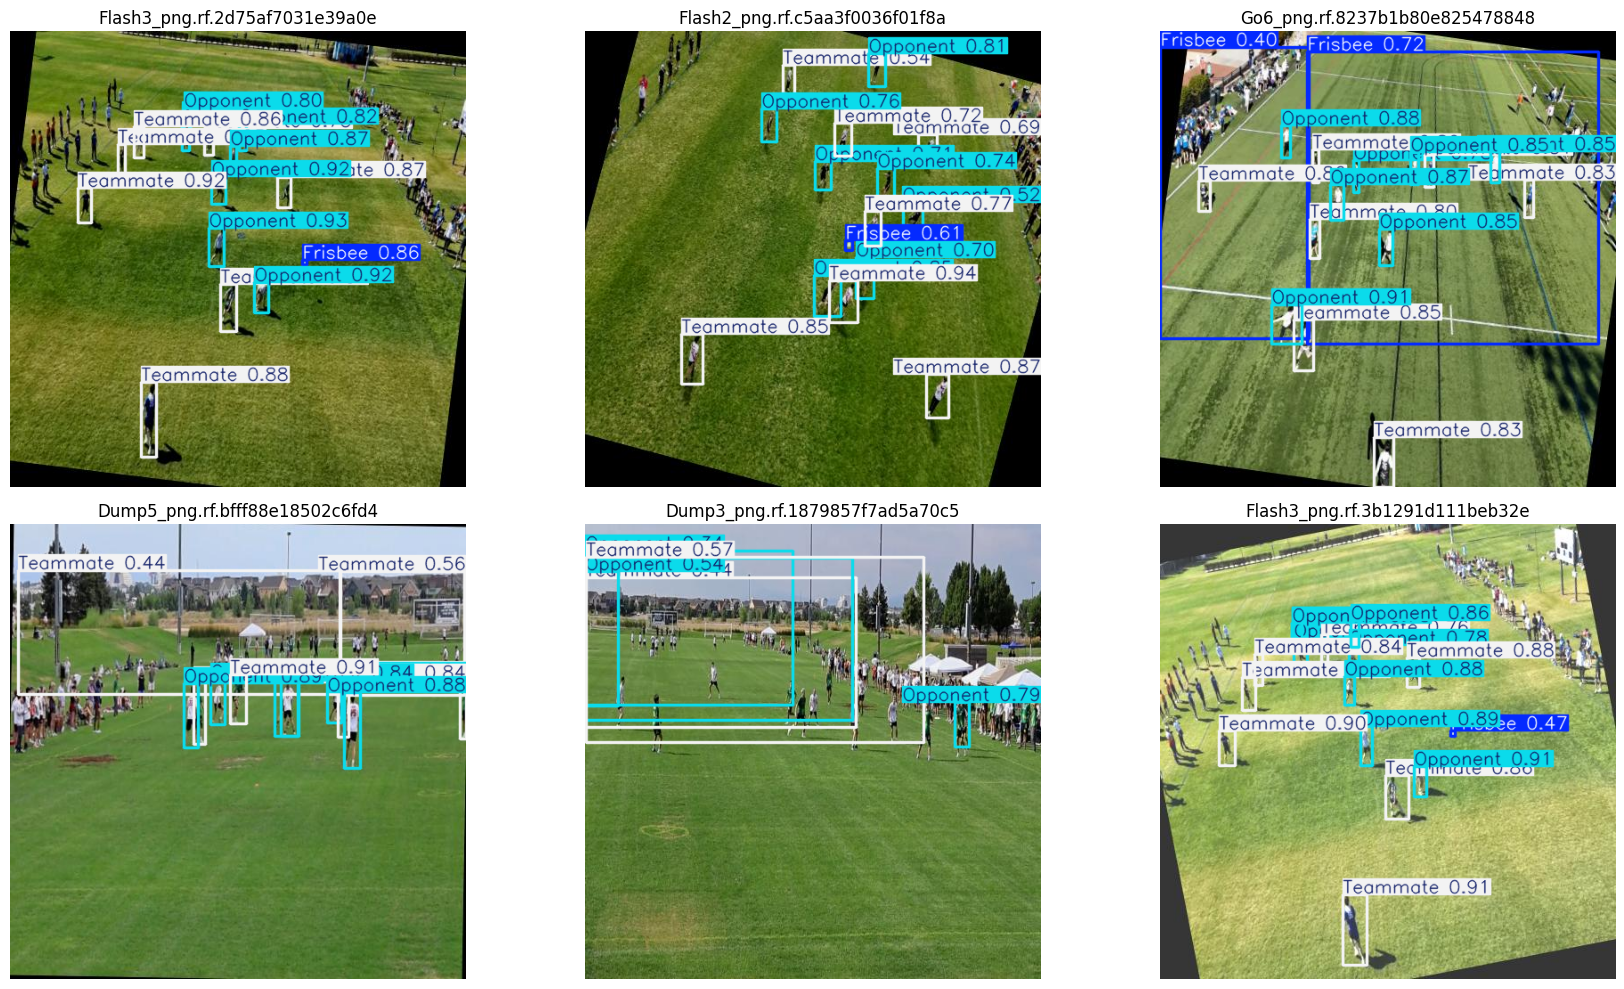

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2, os, random

model = YOLO('/content/drive/MyDrive/frisbee_model/run1/weights/best.pt')

# Run prediction on a few validation images
val_images = os.listdir('/content/Frisbee-2/valid/images')
random.shuffle(val_images)
samples = val_images[:6]  # show 6 random ones

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, img_file in enumerate(samples):
    img_path = f'/content/Frisbee-2/valid/images/{img_file}'
    results = model.predict(img_path, conf=0.3, verbose=False)

    # Draw predictions on image
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[i].imshow(annotated)
    axes[i].set_title(img_file[:30])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Validation set metrics
val_results = model.val(
    data='/content/Frisbee-2/data.yaml',
    split='val',
    plots=True,
    save_dir='/content/drive/MyDrive/frisbee_model/run12/val_eval'
)

# Test set metrics
test_results = model.val(
    data='/content/Frisbee-2/data.yaml',
    split='test',
    plots=True,
    save_dir='/content/drive/MyDrive/frisbee_model/run12/test_eval'
)

print(f"Val  mAP50: {val_results.box.map50:.3f}")
print(f"Test mAP50: {test_results.box.map50:.3f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1260.0±369.7 MB/s, size: 42.4 KB)
val: Scanning /content/Frisbee-2/valid/labels... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 1.2Kit/s 0.1s
val: New cache created: /content/Frisbee-2/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1778, len(boxes) = 1853. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.5it/s 5.8s
                   all        130       1853      0.841      0.852      0.864      0.618
               Frisbee        130        130      0.701      0.669      0.629      0.313
              Opponent        130        863      0.917      0.948 

**DATA CLEANUP AND DOT MAP SCRIPT**

In [ ]:
import os, re

for img_dir in [
    '/content/Frisbee-2/train/images',
    '/content/Frisbee-2/valid/images',
    '/content/Frisbee-2/test/images'
]:
    if not os.path.exists(img_dir):
        continue
    for f in os.listdir(img_dir):
        if f.lower().startswith('ho') and not f.lower().startswith('hostack'):
            old_path = os.path.join(img_dir, f)
            new_name = 'HoStack' + f[2:]
            os.rename(old_path, os.path.join(img_dir, new_name))
            print(f"Renamed: {f} → {new_name}")

print("Done!")

Renamed: Ho1_png.rf.fe1b4c15bd8eccc2b582c3195c738695.jpg → HoStack1_png.rf.fe1b4c15bd8eccc2b582c3195c738695.jpg
Renamed: Ho1_png.rf.1cee38fc5ff3a2ab748a162db3e04f47.jpg → HoStack1_png.rf.1cee38fc5ff3a2ab748a162db3e04f47.jpg
Renamed: Ho1_png.rf.fb2345289c4b437fc1129b30c00bcc9e.jpg → HoStack1_png.rf.fb2345289c4b437fc1129b30c00bcc9e.jpg
Renamed: Ho1_png.rf.9fa8ffc01763f8c085d669e6f3fa3144.jpg → HoStack1_png.rf.9fa8ffc01763f8c085d669e6f3fa3144.jpg
Renamed: Ho1_png.rf.63ac7f8b4e71600f2ab457cff9c742ba.jpg → HoStack1_png.rf.63ac7f8b4e71600f2ab457cff9c742ba.jpg
Renamed: Ho1_png.rf.fede12ea4ff0a42bfe30b57d9954cb8b.jpg → HoStack1_png.rf.fede12ea4ff0a42bfe30b57d9954cb8b.jpg
Renamed: Ho1_png.rf.96f64df6c48355d9b8a4786cdbbd526a.jpg → HoStack1_png.rf.96f64df6c48355d9b8a4786cdbbd526a.jpg
Renamed: Ho1_png.rf.0f38ec2c181c49cbbc2a44ac05e8a9d3.jpg → HoStack1_png.rf.0f38ec2c181c49cbbc2a44ac05e8a9d3.jpg
Renamed: Ho1_png.rf.039582eaeffa5faacc807f94c6218c23.jpg → HoStack1_png.rf.039582eaeffa5faacc807f94c6218

In [ ]:
import shutil
shutil.rmtree('/content/drive/MyDrive/frisbee_dotmaps')
print("Cleared old dot maps")

Cleared old dot maps


🚀 Processing and saving all dot maps...
✅ All dot maps saved to /content/drive/MyDrive/frisbee_dotmaps


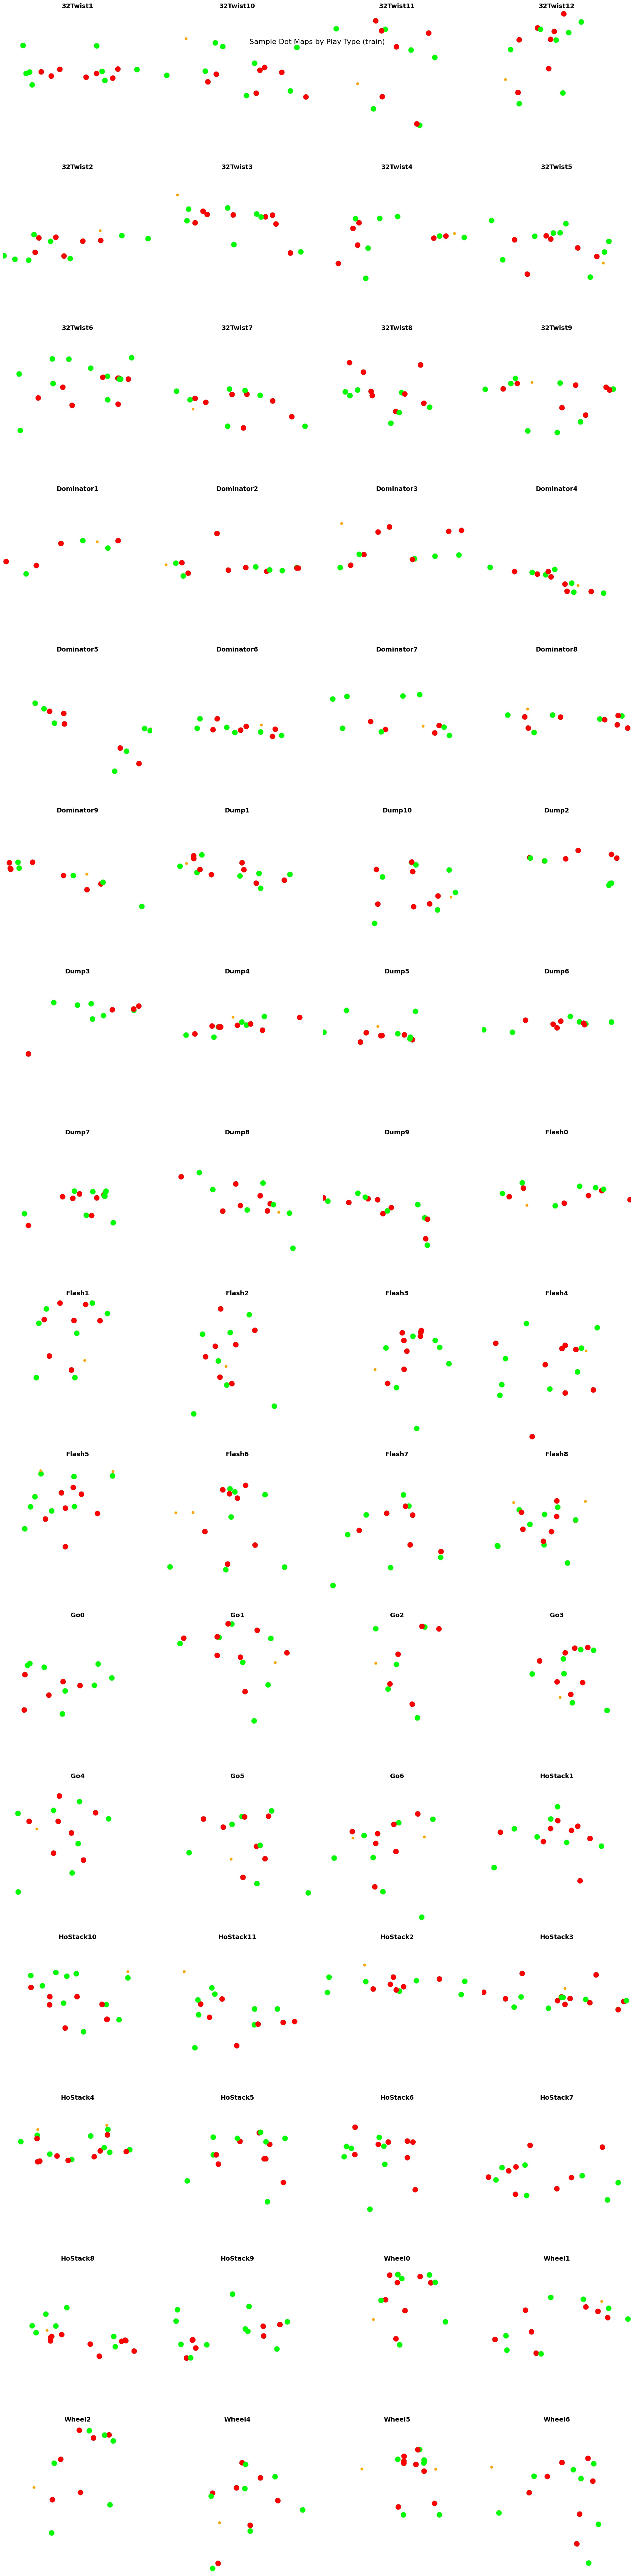

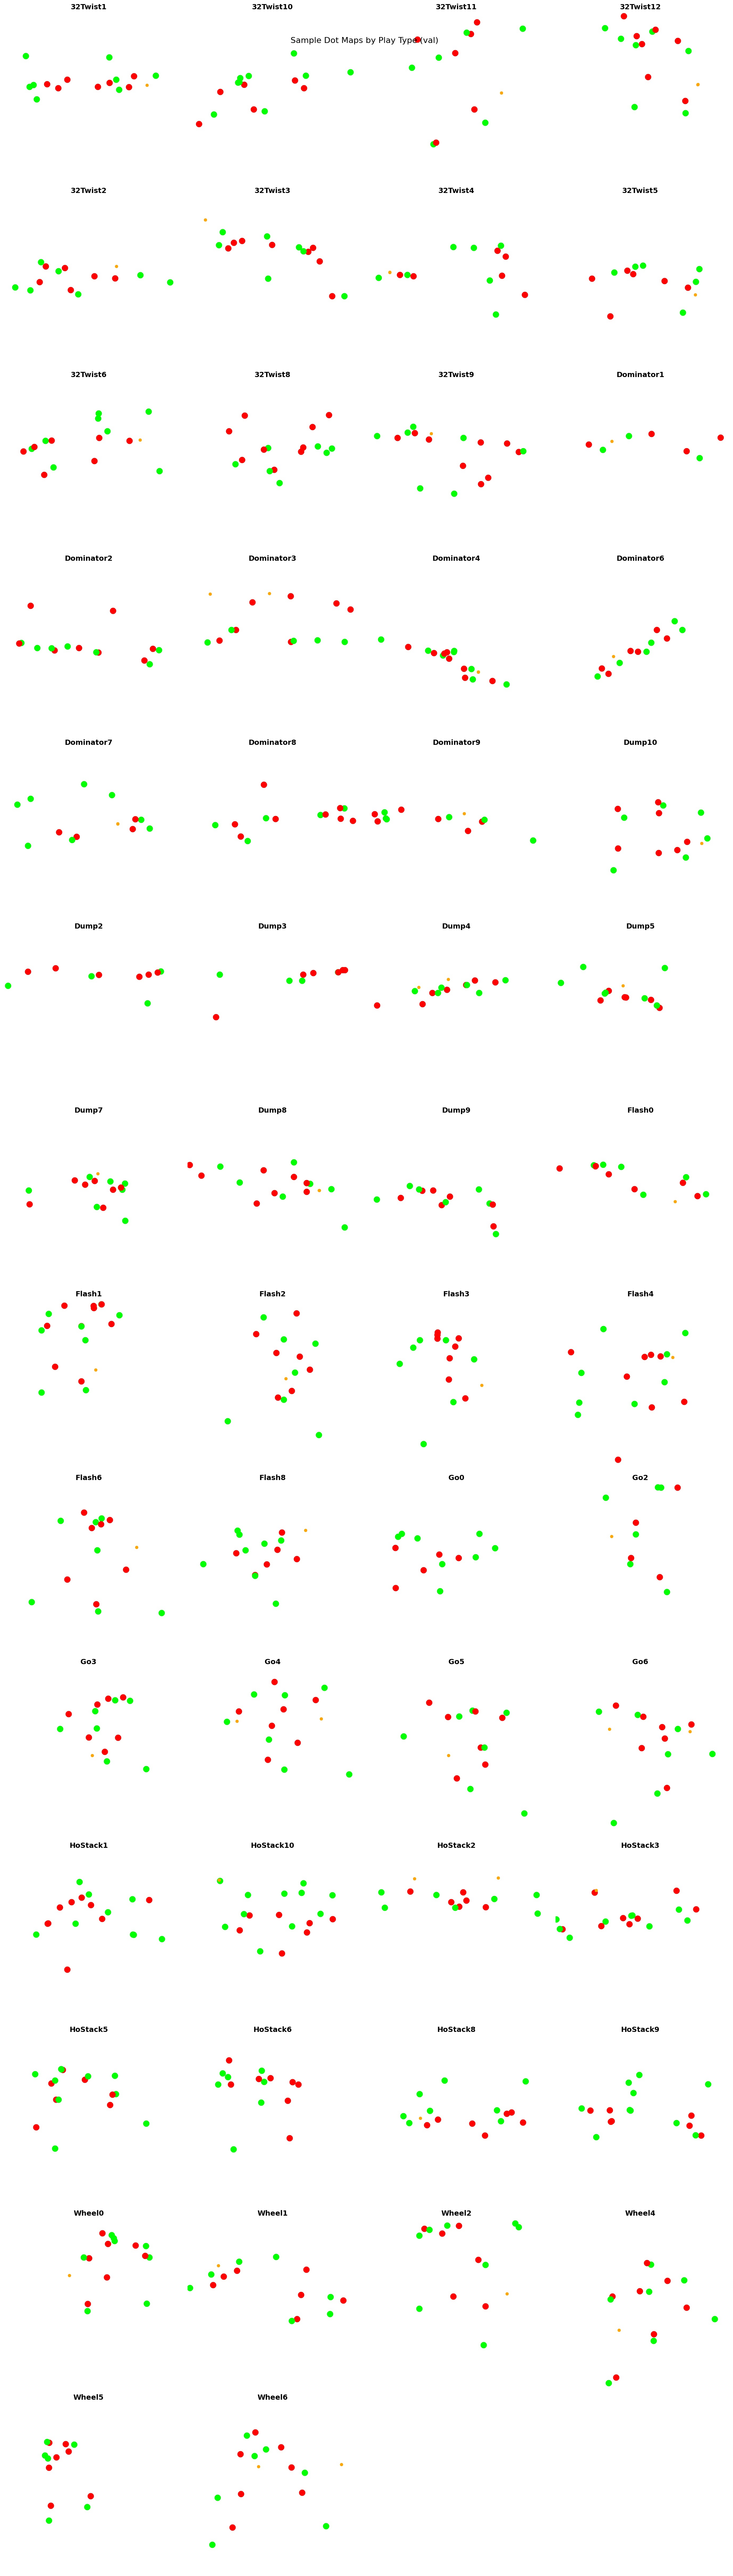

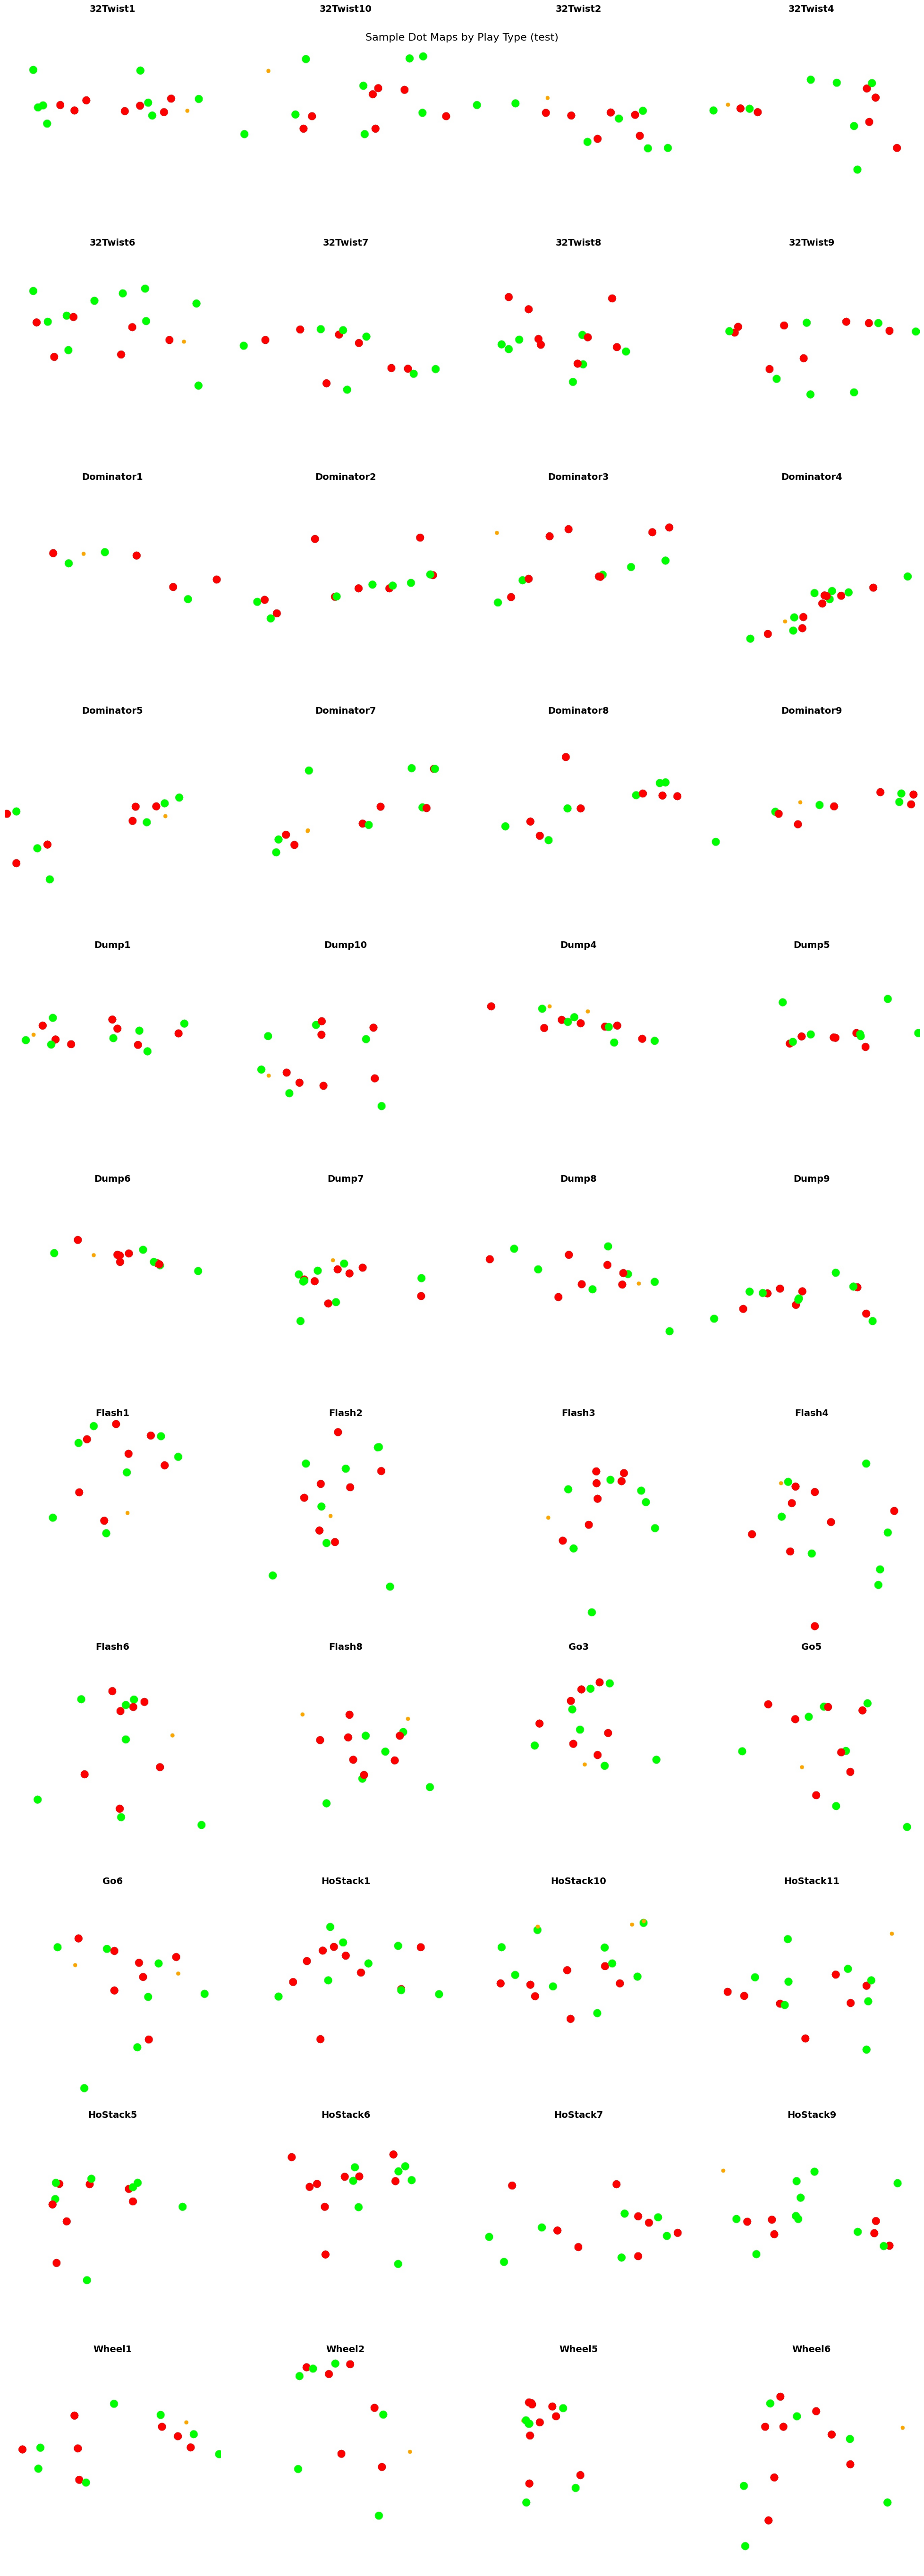

In [ ]:
import os, cv2, re, random, math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

MODEL_PATH = '/content/drive/MyDrive/frisbee_model/run1/weights/best.pt'
OUTPUT_BASE = Path('/content/drive/MyDrive/frisbee_dotmaps')
SPLITS = {
    "train": "/content/Frisbee-2/train/images",
    "val":   "/content/Frisbee-2/valid/images",
    "test":  "/content/Frisbee-2/test/images"
}
COLORS = {0: (0, 165, 255), 1: (0, 0, 255), 2: (0, 255, 0)}
RADII = {0: 6, 1: 12, 2: 12}

model = YOLO(MODEL_PATH)

RENAME_MAP = {'Ho': 'HoStack'}

def clean_label(filename):
    stem = filename.rsplit('.', 1)[0]
    label = re.sub(r'(_png\.rf\..*|\d+)$', '', stem, flags=re.IGNORECASE)
    return RENAME_MAP.get(label, label)

def create_dotmap(img_path, model, size=(640, 640)):
    res = model.predict(img_path, conf=0.3, verbose=False)[0]
    m = np.ones((size[1], size[0], 3), dtype=np.uint8) * 255
    sh = res.orig_shape
    for box in res.boxes:
        cls, (cx, cy, _, _) = int(box.cls), box.xywh[0].tolist()
        px, py = int(cx * (size[0]/sh[1])), int(cy * (size[1]/sh[0]))
        if cls in COLORS:
            cv2.circle(m, (px, py), RADII[cls], COLORS[cls], -1)
    return m

print("🚀 Processing and saving all dot maps...")

for split, img_dir in SPLITS.items():
    img_path_obj = Path(img_dir)
    if not img_path_obj.exists():
        continue
    for img_file in img_path_obj.glob('*.[jJ][pP][gG]'):
        play = clean_label(img_file.name)
        out_dir = OUTPUT_BASE / split / play
        out_dir.mkdir(parents=True, exist_ok=True)
        dot_map = create_dotmap(str(img_file), model)
        cv2.imwrite(str(out_dir / img_file.name), dot_map)

print(f"All dot maps saved to {OUTPUT_BASE}")

for split in SPLITS.keys():
    dotmap_base = str(OUTPUT_BASE / split)
    if not os.path.exists(dotmap_base):
        continue
    labels = sorted([d for d in os.listdir(dotmap_base) if os.path.isdir(os.path.join(dotmap_base, d))])
    if not labels:
        continue
    cols = 4
    rows = math.ceil(len(labels) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = np.array(axes).flatten()
    i = 0
    for label in labels:
        label_dir = os.path.join(dotmap_base, label)
        files = [f for f in os.listdir(label_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if not files:
            continue
        sample = random.choice(files)
        img = cv2.imread(os.path.join(label_dir, sample))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(label, fontsize=14, fontweight='bold')
        axes[i].axis('off')
        i += 1
    for j in range(i, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Sample Dot Maps by Play Type ({split})', fontsize=16)
    plt.tight_layout()
    plt.show()

**MERGING DATA INTO 7 CLASSES, FURTHER AUGMENTATION BEFORE TRAINING CNNs**

In [ ]:
import os, re, shutil
from pathlib import Path

for split_imgs in [
    '/content/Frisbee-2/train/images',
    '/content/Frisbee-2/valid/images',
    '/content/Frisbee-2/test/images'
]:
    if not os.path.exists(split_imgs):
        continue
    for f in os.listdir(split_imgs):
        if f.lower().startswith('ho') and not f.lower().startswith('hostack'):
            old_path = os.path.join(split_imgs, f)
            new_name = 'HoStack' + f[2:]
            os.rename(old_path, os.path.join(split_imgs, new_name))
            print(f"Renamed: {f} → {new_name}")

dotmap_base = Path('/content/drive/MyDrive/frisbee_dotmaps')

RENAME_MAP = {'Ho': 'HoStack'}

def get_base_class(folder_name):
    if folder_name in RENAME_MAP:
        return RENAME_MAP[folder_name]
    return re.sub(r'\d+$', '', folder_name).strip()

for split in ['train', 'val', 'test']:
    split_dir = dotmap_base / split
    if not split_dir.exists():
        continue
    for folder in list(split_dir.iterdir()):
        if not folder.is_dir():
            continue
        base = get_base_class(folder.name)
        if base != folder.name:
            target = split_dir / base
            target.mkdir(exist_ok=True)
            for f in folder.glob('*'):
                shutil.move(str(f), str(target / f.name))
            shutil.rmtree(str(folder))
            print(f"Merged {folder.name} → {base}")

print("\nDone! Final class folders:")
for split in ['train', 'val', 'test']:
    split_dir = dotmap_base / split
    if split_dir.exists():
        dirs = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        print(f"  {split}: {dirs}")

Merged Dominator5 → Dominator
Merged HoStack9 → HoStack
Merged Dump6 → Dump
Merged Go0 → Go
Merged Go5 → Go
Merged Flash1 → Flash
Merged HoStack5 → HoStack
Merged Flash7 → Flash
Merged HoStack8 → HoStack
Merged 32Twist5 → 32Twist
Merged Dominator8 → Dominator
Merged Wheel6 → Wheel
Merged Go4 → Go
Merged 32Twist4 → 32Twist
Merged Go6 → Go
Merged HoStack6 → HoStack
Merged Wheel1 → Wheel
Merged HoStack2 → HoStack
Merged HoStack3 → HoStack
Merged 32Twist12 → 32Twist
Merged 32Twist11 → 32Twist
Merged Go1 → Go
Merged Flash8 → Flash
Merged Dominator4 → Dominator
Merged 32Twist8 → 32Twist
Merged Dump8 → Dump
Merged Dump10 → Dump
Merged Dump7 → Dump
Merged Dominator1 → Dominator
Merged Dump1 → Dump
Merged Dump4 → Dump
Merged HoStack1 → HoStack
Merged Wheel2 → Wheel
Merged Dump5 → Dump
Merged 32Twist10 → 32Twist
Merged Flash6 → Flash
Merged 32Twist2 → 32Twist
Merged Dominator6 → Dominator
Merged Go2 → Go
Merged Flash5 → Flash
Merged Wheel0 → Wheel
Merged Go3 → Go
Merged HoStack10 → HoStack
Merge

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = '/content/drive/MyDrive/frisbee_dotmaps/train'
val_dir   = '/content/drive/MyDrive/frisbee_dotmaps/val'
test_dir  = '/content/drive/MyDrive/frisbee_dotmaps/test'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)

val_dataset = datasets.ImageFolder(val_dir, transform=transform) if os.path.exists(val_dir) else None
test_dataset = datasets.ImageFolder(test_dir, transform=transform) if os.path.exists(test_dir) else None

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) if val_dataset else None
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) if test_dataset else None

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))
print("Train size:", len(train_dataset))
if val_dataset:
    print("Val size:", len(val_dataset))
if test_dataset:
    print("Test size:", len(test_dataset))

Classes: ['32Twist', 'Dominator', 'Dump', 'Flash', 'Go', 'HoStack', 'Wheel']
Number of classes: 7
Train size: 454
Val size: 130
Test size: 65


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset.transform = train_transforms
val_dataset.transform = val_transforms
test_dataset.transform = val_transforms

**RUN THE NEXT TWO CELLS FOR RESNET MODEL**

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

num_classes = len(train_dataset.classes)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

epochs = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 7

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"Best model saved (val loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(torch.load('best_model.pt'))
print("Best model reloaded")

Epoch 1/30 | Train Loss: 1.9843 | Train Acc: 0.1960 | Val Loss: 1.8313 | Val Acc: 0.3231
  ✅ Best model saved (val loss: 1.8313)
Epoch 2/30 | Train Loss: 1.8252 | Train Acc: 0.2467 | Val Loss: 1.7094 | Val Acc: 0.2846
  ✅ Best model saved (val loss: 1.7094)
Epoch 3/30 | Train Loss: 1.7281 | Train Acc: 0.2974 | Val Loss: 1.6133 | Val Acc: 0.3385
  ✅ Best model saved (val loss: 1.6133)
Epoch 4/30 | Train Loss: 1.5703 | Train Acc: 0.3722 | Val Loss: 1.5464 | Val Acc: 0.3846
  ✅ Best model saved (val loss: 1.5464)
Epoch 5/30 | Train Loss: 1.5061 | Train Acc: 0.4449 | Val Loss: 1.4793 | Val Acc: 0.4538
  ✅ Best model saved (val loss: 1.4793)
Epoch 6/30 | Train Loss: 1.4122 | Train Acc: 0.4670 | Val Loss: 1.3675 | Val Acc: 0.4846
  ✅ Best model saved (val loss: 1.3675)
Epoch 7/30 | Train Loss: 1.3557 | Train Acc: 0.5242 | Val Loss: 1.3261 | Val Acc: 0.4846
  ✅ Best model saved (val loss: 1.3261)
Epoch 8/30 | Train Loss: 1.2806 | Train Acc: 0.5529 | Val Loss: 1.2673 | Val Acc: 0.4769
  ✅ Best

**RUN THE NEXT TWO CELLS FOR THE SELF-BUILT CNN**

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

class FrisbeeNet(nn.Module):
    def __init__(self, num_classes):
        super(FrisbeeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model2 = FrisbeeNet(num_classes).to(device)
print(model)

FrisbeeNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

optimizer = optim.Adam(model2.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model2.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model2(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

epochs = 10
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(epochs):
    model2.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model2(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model2, val_loader)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model2.state_dict(), 'best_model2.pt')
        print(f"Best model saved (val loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

model2.load_state_dict(torch.load('best_model2.pt'))
print("Best model reloaded")

Epoch 1/10 | Train Loss: 3.7457 | Train Acc: 0.1256 | Val Loss: 4.2754 | Val Acc: 0.0577
  ✅ Best model saved (val loss: 4.2754)
Epoch 2/10 | Train Loss: 3.6640 | Train Acc: 0.1509 | Val Loss: 4.2743 | Val Acc: 0.0731
  ✅ Best model saved (val loss: 4.2743)
Epoch 3/10 | Train Loss: 3.6033 | Train Acc: 0.1443 | Val Loss: 4.3821 | Val Acc: 0.0538
  ⚠️ No improvement (1/5)
Epoch 4/10 | Train Loss: 3.6022 | Train Acc: 0.1454 | Val Loss: 4.3696 | Val Acc: 0.0615
  ⚠️ No improvement (2/5)
Epoch 5/10 | Train Loss: 3.5936 | Train Acc: 0.1300 | Val Loss: 4.3412 | Val Acc: 0.0692
  ⚠️ No improvement (3/5)
Epoch 6/10 | Train Loss: 3.5414 | Train Acc: 0.1476 | Val Loss: 4.2924 | Val Acc: 0.0538
  ⚠️ No improvement (4/5)
Epoch 7/10 | Train Loss: 3.4981 | Train Acc: 0.1597 | Val Loss: 4.3617 | Val Acc: 0.0731
  ⚠️ No improvement (5/5)
🛑 Early stopping triggered
✅ Best model reloaded


**TEST ACCURACY AND SAMPLE DOT MAP CLASSIFICATION**

In [ ]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

if test_loader:
    test_loss, test_acc = evaluate(model, test_loader)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Acc:  {test_acc:.4f}")

Test Loss: 0.3313
Test Acc:  0.9385


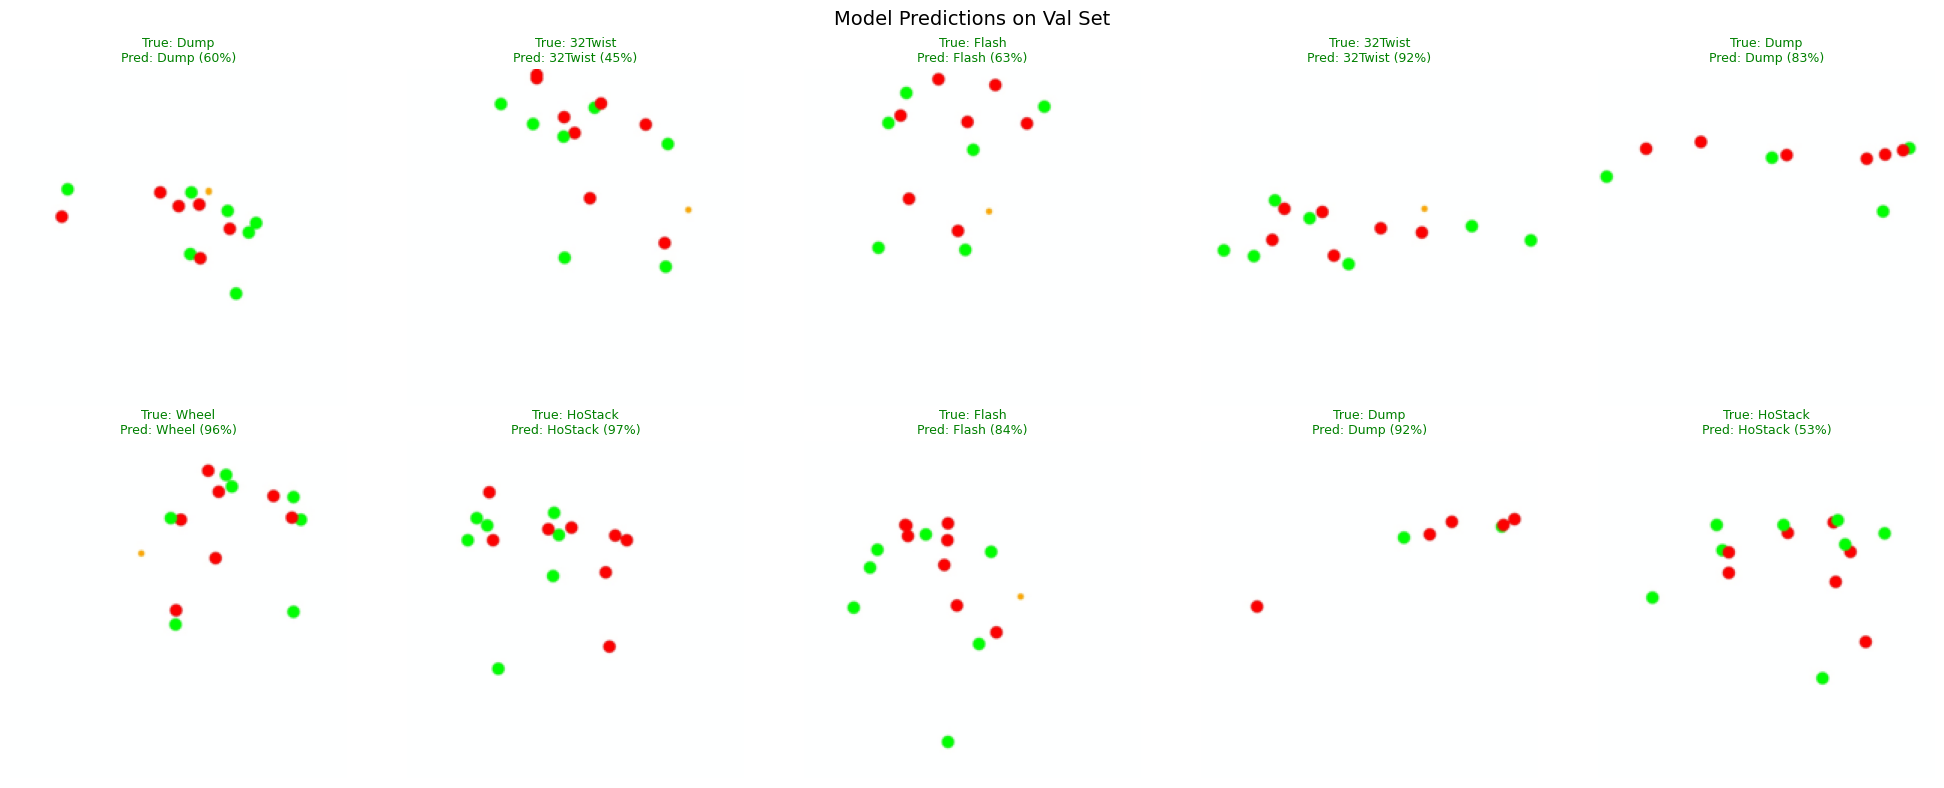

In [ ]:
import matplotlib.pyplot as plt
import random

# Check a few val samples and what the model predicts
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

val_classes = val_dataset.classes

for i in range(10):
    idx = random.randint(0, len(val_dataset) - 1)
    img, true_label = val_dataset[idx]

    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        probs = torch.softmax(output, dim=1)[0]
        pred_label = probs.argmax().item()
        confidence = probs.max().item()

    img_np = img.permute(1, 2, 0).numpy()
    # Unnormalize for display
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    img_np = (img_np * std + mean).clip(0, 1)

    correct = pred_label == true_label
    axes[i].imshow(img_np)
    axes[i].set_title(
        f"True: {val_classes[true_label]}\nPred: {val_classes[pred_label]} ({confidence:.0%})",
        color='green' if correct else 'red', fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Model Predictions on Val Set", fontsize=14)
plt.tight_layout()
plt.show()

**SAVING AND LOADING WEIGHTS FOR FUTURE SESSIONS**

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes
}, '/content/drive/MyDrive/frisbee_dotmaps_cnn_resnet18.pth')

print("Saved model to Drive.")

Saved model to Drive.


In [ ]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from ultralytics import YOLO
from PIL import Image

YOLO_PATH       = '/content/drive/MyDrive/frisbee_model/run1/weights/best.pt'
CLASSIFIER_PATH = '/content/drive/MyDrive/frisbee_dotmaps_cnn_resnet18.pth'

yolo_model = YOLO(YOLO_PATH)

checkpoint  = torch.load(CLASSIFIER_PATH)
classes     = checkpoint['classes']
num_classes = len(classes)

classifier = models.resnet18(weights=None)
classifier.fc = nn.Linear(classifier.fc.in_features, num_classes)
classifier.load_state_dict(checkpoint['model_state_dict'])
classifier = classifier.to(device)
classifier.eval()

print("Classes:", classes)
print("Classifier loaded successfully")

Classes: ['32Twist', 'Dominator', 'Dump', 'Flash', 'Go', 'HoStack', 'Wheel']
Classifier loaded successfully


**FINAL FUNCTION TO CLASSIFY ANY IMAGE**

In [ ]:
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

COLORS = {0: (0, 165, 255), 1: (0, 0, 255), 2: (0, 255, 0)}
RADII  = {0: 6, 1: 12, 2: 12}

def predict_play(image_path):
    res = yolo_model.predict(image_path, conf=0.3, verbose=False)[0]
    annotated = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

    size = (640, 640)
    dot_map = np.ones((size[1], size[0], 3), dtype=np.uint8) * 255
    sh = res.orig_shape
    for box in res.boxes:
        cls, (cx, cy, _, _) = int(box.cls), box.xywh[0].tolist()
        px = int(cx * (size[0] / sh[1]))
        py = int(cy * (size[1] / sh[0]))
        if cls in COLORS:
            cv2.circle(dot_map, (px, py), RADII[cls], COLORS[cls], -1)
    dot_map_rgb = cv2.cvtColor(dot_map, cv2.COLOR_BGR2RGB)

    pil_img = Image.fromarray(dot_map_rgb)
    tensor  = infer_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = classifier(tensor)
        probs  = torch.softmax(output, dim=1)[0]
        top3   = probs.topk(3)

    pred_label = classes[probs.argmax().item()]
    confidence = probs.max().item()

    orig = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(orig)
    axes[0].set_title("Step 1: Original Image", fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(annotated)
    axes[1].set_title("Step 2: YOLO Detections", fontsize=13)
    axes[1].axis('off')

    axes[2].imshow(dot_map_rgb)
    axes[2].set_title("Step 3: Dot Map", fontsize=13)
    axes[2].axis('off')

    plt.suptitle(
        f"Predicted Play: {pred_label} ({confidence:.0%} confidence)\n"
        f"Top 3: " + " | ".join([f"{classes[i]} ({probs[i]:.0%})" for i in top3.indices]),
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    return pred_label, confidence


Saving Go2.png to Go2.png
Moved Go2.png


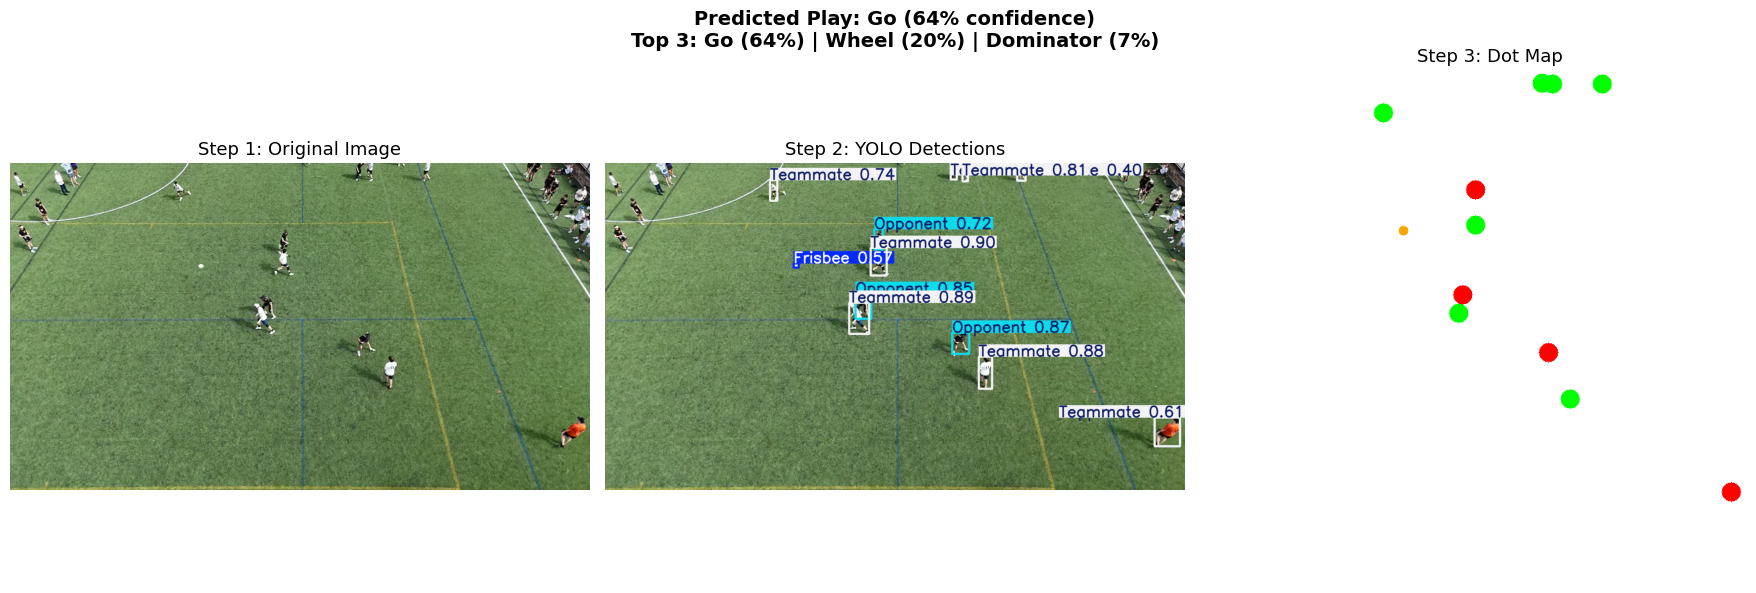

('Go', 0.6408654451370239)

In [ ]:
from google.colab import files
uploaded = files.upload()

import shutil
for filename in uploaded.keys():
    shutil.move(filename, f'/content/Frisbee-2/test/images/{filename}')
    print(f"Moved {filename}")

predict_play(f'/content/Frisbee-2/test/images/{filename}')

In [1]:
from google.colab import userdata
!git config --global user.email "cyz3@duke.edu"
!git config --global user.name "Colin Zeng"

In [2]:
!git clone https://github.com/cyzeng29/frisbee-classifier.git
%cd frisbee-classifier

Cloning into 'frisbee-classifier'...
/content/frisbee-classifier


In [4]:
!cp /content/FrisbeeClassification.ipynb .

cp: cannot stat '/content/FrisbeeClassification.ipynb': No such file or directory


In [6]:
!find /content -name "*.ipynb" 2>/dev/null

In [7]:
from google.colab import files
uploaded = files.upload()  # select the .ipynb you just downloaded

KeyboardInterrupt: 